In [1]:
import os
import sys
#print(sys.executable)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import root_scalar
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
import glob

In [2]:
'''$folder = "C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data"
$excel = New-Object -ComObject Excel.Application
$excel.Visible = $false

Get-ChildItem $folder -Filter *.csv | ForEach-Object {
    $wb = $excel.Workbooks.Open($_.FullName)
    $new = $_.FullName.Replace(".csv", ".xlsx")
    $wb.SaveAs($new, 51)
    $wb.Close()
}

$excel.Quit()
'''
'''powershell에서'''

'powershell에서'

In [3]:
Time = {}
CH1 = {}
CH2 = {}


for i in range(0,10):   # 1 ~ 27
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    print(os.path.exists(path))
    print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

'''Time[5] → 5번 파일의 TIME
CH1[12] → 12번 파일의 CH1
CH2[27] → 27번 파일의 CH2
순서아니고 뒷에 진짜 숫자'''


0
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0000.xlsx
1
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0001.xlsx
2
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0002.xlsx
3
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0003.xlsx
4
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0004.xlsx
5
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0005.xlsx
6
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0006.xlsx
7
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0007.xlsx
8
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0008.xlsx
9
True
Reading: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0009.xlsx


'Time[5] → 5번 파일의 TIME\nCH1[12] → 12번 파일의 CH1\nCH2[27] → 27번 파일의 CH2\n순서아니고 뒷에 진짜 숫자'

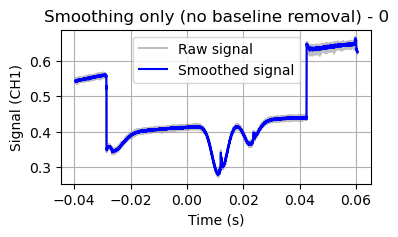

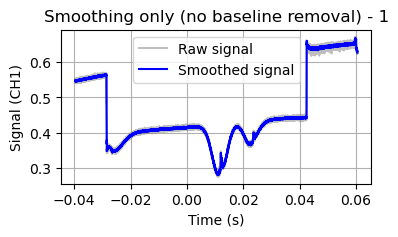

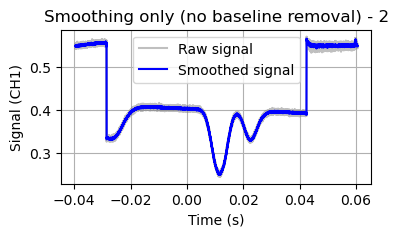

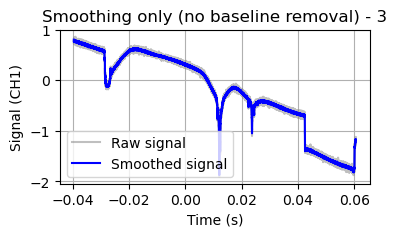

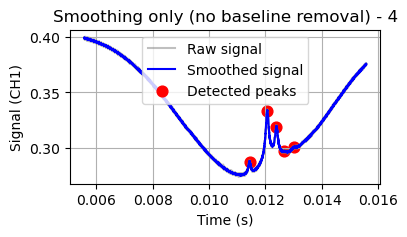

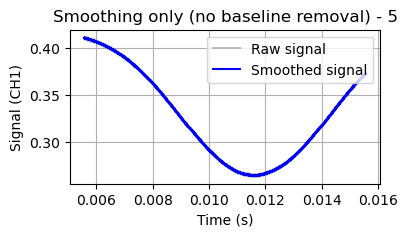

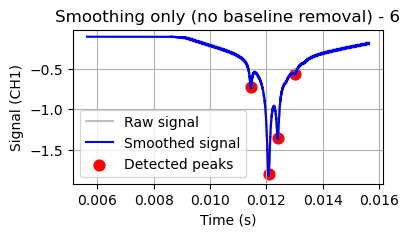

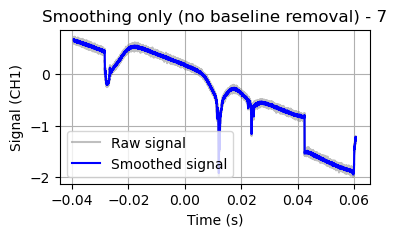

In [123]:

from scipy.signal import savgol_filter

def plot_smoothed_signal(i):

    # ----------------------------
    # Load data
    # ----------------------------
    
    t = Time[i]
    y = CH1[i]

    # ----------------------------
    # Smoothing only (NO baseline removal)
    # ----------------------------
    # window는 signal 길이에 따라 자동 결정 (너무 세게 안 깎이도록)
    #win = max(21, (len(y) // 200) * 2 + 1)
    win = 21
    y_smooth = savgol_filter(y, win, polyorder=3)

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(4,2))
    plt.plot(t, y, color='gray', alpha=0.5, label='Raw signal')
    plt.plot(t, y_smooth, color='blue', label='Smoothed signal')

    if f"data{i}_T" in globals() and f"data{i}_1" in globals():
        plt.scatter(globals()[f"data{i}_T"], globals()[f"data{i}_1"], c='red', s=60, label="Detected peaks")


    plt.title(f"Smoothing only (no baseline removal) - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    plt.legend()
    plt.show()


# 예시 실행
for i in range(0,8):
    #path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    plot_smoothed_signal(i)



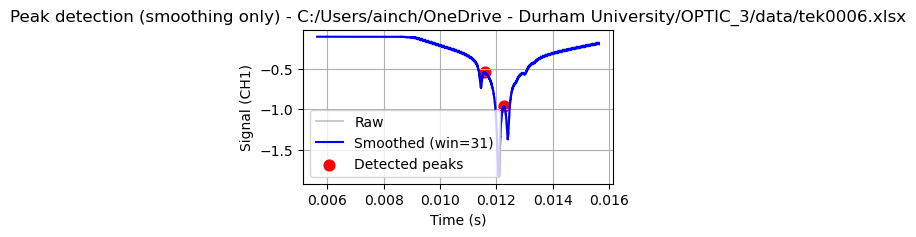


▶ FILE: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0006.xlsx
window_length = 31, polyorder = 3
Detected peaks: 2
  peak @ 0.011593
  peak @ 0.012270


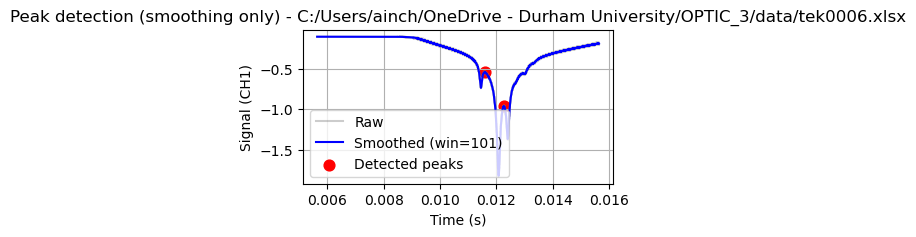


▶ FILE: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0006.xlsx
window_length = 101, polyorder = 3
Detected peaks: 2
  peak @ 0.011594
  peak @ 0.012271


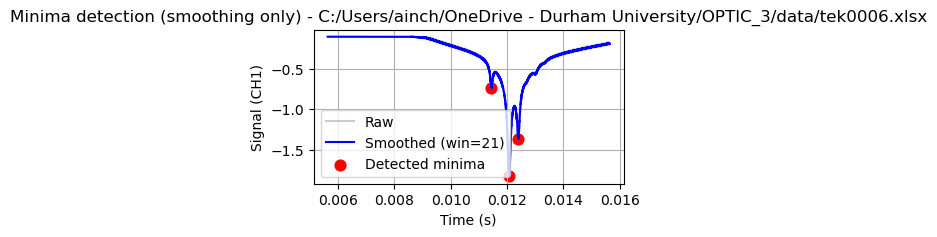


▶ FILE: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0006.xlsx
window_length = 21, polyorder = 3
Detected minima: 3
  minima @ 0.011450
  minima @ 0.012078
  minima @ 0.012404


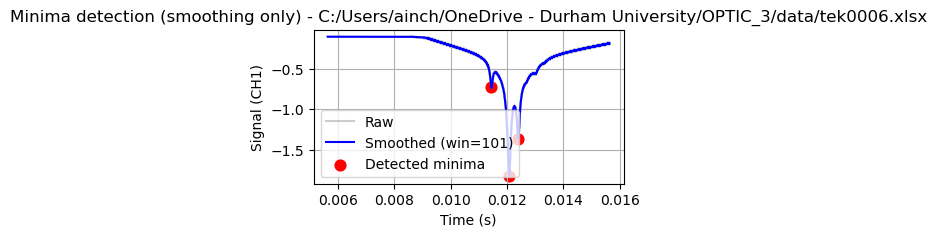


▶ FILE: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0006.xlsx
window_length = 101, polyorder = 3
Detected minima: 3
  minima @ 0.011451
  minima @ 0.012080
  minima @ 0.012403


In [121]:
from scipy.signal import savgol_filter, find_peaks
def plot_smoothed_with_peaks1(fname, window_length=41, polyorder=3,
                             prom_scale=0.2, dist_scale=250):

    # ----------------------------
    # 1) Load data
    # ----------------------------
    df = pd.read_excel(fname, skiprows=20)
    t = df["TIME"].values
    y = df["CH1"].values

    # ----------------------------
    # 2) Smoothing (baseline 제거 X)
    # ----------------------------
    # window_length는 smoothing 강도 조절용
    # 반드시 홀수여야 함
    if window_length % 2 == 0:
        window_length += 1

    y_s = savgol_filter(y, window_length, polyorder)

    # ----------------------------
    # 3) Peak detection
    # ----------------------------
    # prominence는 smoothing 정도에 따라 자동 조절됨
    prom = np.std(y_s) * prom_scale
    dist = len(y) // dist_scale

    peaks, _ = find_peaks(y_s, prominence=prom, distance=dist)
    peak_times = t[peaks]
    peak_values = y_s[peaks]

    # ----------------------------
    # 4) Plot
    # ----------------------------
    plt.figure(figsize=(4,2))
    plt.plot(t, y, color='gray', alpha=0.4, label="Raw")
    plt.plot(t, y_s, color='blue', label=f"Smoothed (win={window_length})")

    plt.scatter(peak_times, peak_values, c='red', s=60, label="Detected peaks")

    plt.title(f"Peak detection (smoothing only) - {fname}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    plt.legend()
    plt.show()

    # ----------------------------
    # 5) Print numeric result
    # ----------------------------
    print(f"\n▶ FILE: {fname}")
    print(f"window_length = {window_length}, polyorder = {polyorder}")
    print(f"Detected peaks: {len(peak_times)}")
    for pt in peak_times:
        print(f"  peak @ {pt:.6f}")


# ----------------------------
''' 실행 예 (smoothing 정도 바꾸며 비교)'''
# ----------------------------
# 예시 실행
for i in [6]:
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    plot_smoothed_with_peaks1(path, window_length=31) # 약한 smoothing → 작은 peak 민감하게 잡음
    plot_smoothed_with_peaks1(path, window_length=101)# 강한 smoothing → noise 없어지지만 tiny peak는 지워질 수 있음

def plot_smoothed_with_peaks2(fname, window_length=21, polyorder=3,
                             prom_scale=0.2, dist_scale=250):

    # ----------------------------
    # 1) Load data
    # ----------------------------
    df = pd.read_excel(fname, skiprows=20)
    t = df["TIME"].values
    y = df["CH1"].values

    # ----------------------------
    # 2) Smoothing
    # ----------------------------
    if window_length % 2 == 0:
        window_length += 1

    y_s = savgol_filter(y, window_length, polyorder)

    # ----------------------------
    # 3) Minima detection
    # ----------------------------
    prom = np.std(y_s) * prom_scale
    dist = len(y) // dist_scale

    # ★ 핵심: -y_s로 peak 찾기 → minima 검출
    peaks, _ = find_peaks(-y_s, prominence=prom, distance=dist)

    peak_times = t[peaks]
    peak_values = y_s[peaks]   # 실제 최소값

    # ----------------------------
    # 4) Plot
    # ----------------------------
    plt.figure(figsize=(4,2))
    plt.plot(t, y, color='gray', alpha=0.4, label="Raw")
    plt.plot(t, y_s, color='blue', label=f"Smoothed (win={window_length})")

    plt.scatter(peak_times, peak_values, c='red', s=60, label="Detected minima")

    plt.title(f"Minima detection (smoothing only) - {fname}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    plt.legend()
    plt.show()

    # ----------------------------
    # 5) Print numeric result
    # ----------------------------
    print(f"\n▶ FILE: {fname}")
    print(f"window_length = {window_length}, polyorder = {polyorder}")
    print(f"Detected minima: {len(peak_times)}")
    for pt in peak_times:
        print(f"  minima @ {pt:.6f}")


for i in [6]:
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    plot_smoothed_with_peaks2(path, window_length=21) # 약한 smoothing → 작은 peak 민감하게 잡음
    plot_smoothed_with_peaks2(path, window_length=101)# 강한 smoothing → noise 없어지지만 tiny peak는 지워질 수 있음

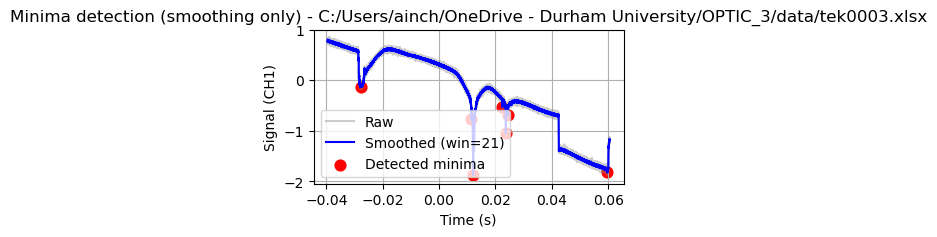


▶ FILE: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0003.xlsx
window_length = 21, polyorder = 3
Detected minima: 7
  minima @ -0.027623
  minima @ 0.011446
  minima @ 0.012077
  minima @ 0.022458
  minima @ 0.023688
  minima @ 0.024431
  minima @ 0.059746


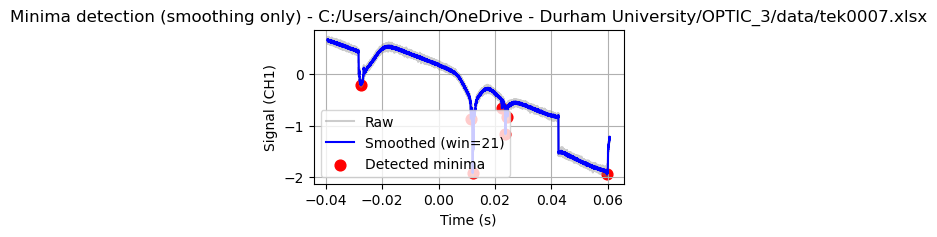


▶ FILE: C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek0007.xlsx
window_length = 21, polyorder = 3
Detected minima: 7
  minima @ -0.027506
  minima @ 0.011442
  minima @ 0.012071
  minima @ 0.022458
  minima @ 0.023692
  minima @ 0.024426
  minima @ 0.059780


In [122]:
for i in [3,7]:
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek000{i}.xlsx"
    plot_smoothed_with_peaks2(path, window_length=21) # 약한 smoothing → 작은 peak 민감하게 잡음
    #plot_smoothed_with_peaks2(path, window_length=101)# 강한 smoothing → noise 없어지지만 tiny peak는 지워질 수 있음

-0.18715576359388034 -0.103631
Max point: 0.0139999 -0.3102930289031725 2.0738593721768135
Min point: 0.0130008 -0.5659081251481841 -0.5716 2.075763212476051 2.08063


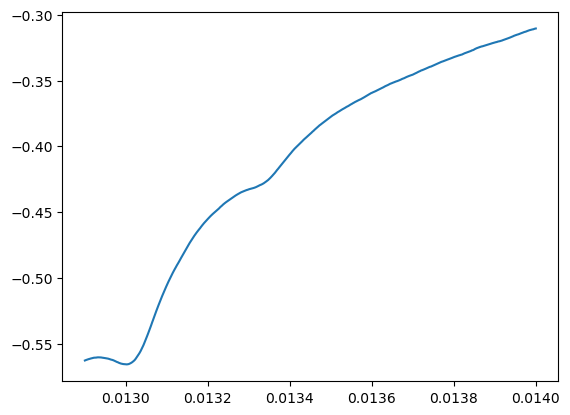

In [207]:
def load_and_smooth(i):
    t = Time[i].values 
    y = CH1[i].values 
    f = CH2[i].values
    win = max(31, (len(y) // 200) * 2 + 1)
    y_smooth = savgol_filter(y, win, polyorder=3)
    f_smooth = savgol_filter(f, win, polyorder=3)
    return t, y, y_smooth,f, f_smooth

t, y, y_smooth,f, f_smooth = load_and_smooth(6)
print(y_smooth[-1],y[0])

def find_max_in_range(t, y_smooth, f,t_min, t_max):
    # 구간 마스크
    mask = (t >= t_min) & (t <= t_max)

    t_sel = t[mask]
    y_sel = y_smooth[mask]
    f_sel = f[mask]
    # 구간에 데이터가 없을 때
    if len(y_sel) == 0:
        print("⚠ 선택한 구간에 데이터가 없습니다.")
        return None, None

    # 최대값 찾기
    idx = np.argmax(y_sel)
    x_max = t_sel[idx]
    y_max = y_sel[idx]
    f_max = f_sel[idx]
    return x_max, y_max, f_max

def find_min_in_range(t, y_smooth, y , f_smooth, f, t_min, t_max):
    # 구간 마스크
    mask = (t >= t_min) & (t <= t_max)

    t_sel = t[mask]
    y_sel = y_smooth[mask]
    f_sel = f_smooth[mask]
    ch1_sel = y[mask] #original
    ch2_sel = f[mask] #original
    # 구간에 데이터가 없을 때
    if len(y_sel) == 0:
        print("⚠ 선택한 구간에 데이터가 없습니다.")
        return None, None

    # 최대값 찾기
    idx = np.argmin(y_sel)
    x_min = t_sel[idx]
    y_min = y_sel[idx]
    f_min = f_sel[idx]
    ch1_min = ch1_sel[idx]
    ch2_min = ch2_sel[idx]
    return x_min, y_min, ch1_min, f_min, ch2_min

t_min = 0.0129
t_max = 0.014

x_max, y_max, f_max = find_max_in_range(t, y_smooth, f_smooth, t_min, t_max)
x_min, y_min, ch1_min, f_min, ch2_min = find_min_in_range(t, y_smooth,y, f_smooth,f, t_min, t_max)
print("Max point:", x_max, y_max, f_max)
print("Min point:", x_min, y_min, ch1_min, f_min, ch2_min)


mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
plt.plot(t_sel,y_sel)
#plt.plot(t,f_smooth) #print((f_smooth[-1]-f_smooth[0])/(t[-1]-t[0]))


In [8]:
time = {}
ch1 = {}
ch2 = {}
for i in range(0,10):
    t, y, y_smooth,f, f_smooth = load_and_smooth(i)
    time[i] = t
    ch1[i] = y_smooth      # y_smooth → ch1
    ch2[i] = f_smooth      # f_smooth → ch2

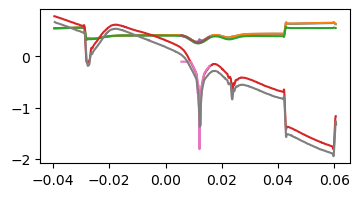

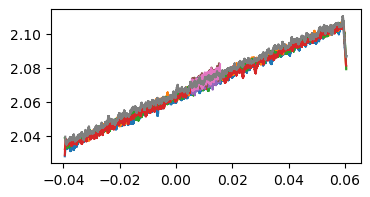

In [9]:
plt.figure(figsize=(4,2))
for i in range(0,8):
    plt.plot(time[i], ch1[i])

plt.figure(figsize=(4,2))
for i in range(0,8):
    plt.plot(time[i],ch2[i])


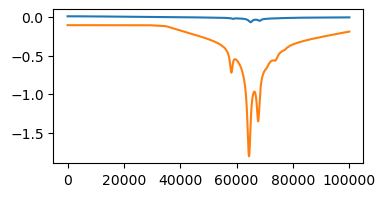

In [10]:
plt.figure(figsize=(4,2))
plt.plot(ch1[5]- ch1[4])
plt.plot(ch1[6])

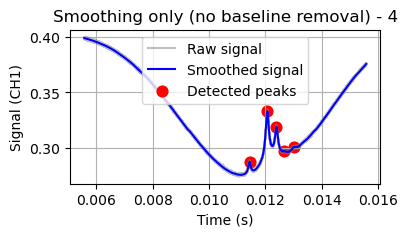

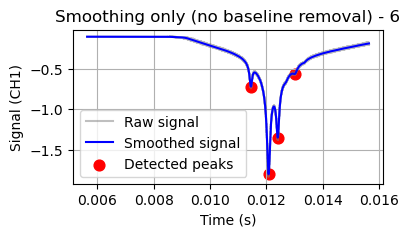

In [11]:
data4_T = [0.0114427, 0.0120711, 0.012397, 0.0126802, 0.0130316]
data4_1 = [0.2874390050049227, 0.33302702376055976, 0.31881418486575, 0.2970975120096744, 0.3008597511899701]
data4_2 = [2.06891, 2.07812, 2.07953, 2.07188, 2.05031]
data6_T = [0.011453, 0.0120791, 0.0124029, 0.0130008]
data6_1 = [-0.72052778409326, -1.8063276656924325, -1.3524347551805662, -0.5659081251481841 ]
data6_2 = [2.0748070597035704, 2.0749573162771995, 2.076009878367027, 2.075763212476051]
plot_smoothed_signal(4)
plot_smoothed_signal(6)

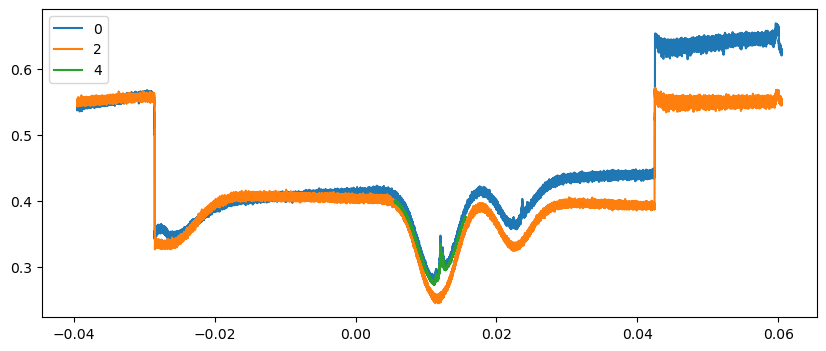

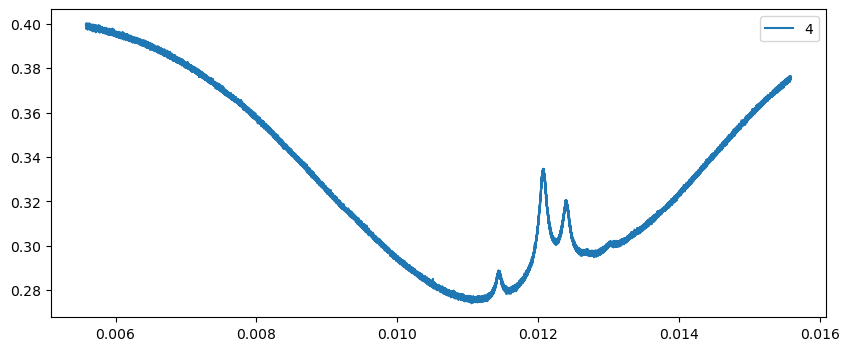

In [12]:
plt.figure(figsize=(10,4))
for i in [0,2,4]:  
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()
plt.figure(figsize=(10,4))
for i in [4]:  
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

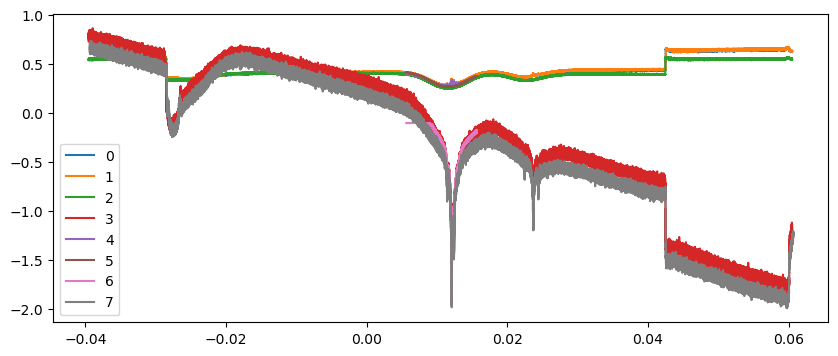

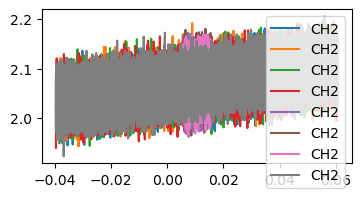

In [13]:
plt.figure(figsize=(10,4))
for i in range(0,8):  
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()
plt.figure(figsize=(4,2))
for i in range(0,8):  
    #plt.plot(Time[i],CH1[i], label=f"{i}")
    plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

In [14]:

for i in range(10,28):   # 1 ~ 27
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

10
True
11
True
12
True
13
True
14
True
15
True
16
True
17
True
18
True
19
True
20
True
21
True
22
True
23
True
24
True
25
True
26
True
27
True


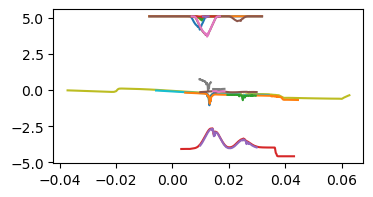

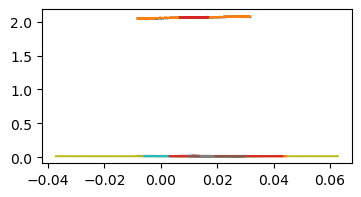

In [15]:
for i in range(10,28):
    t, y, y_smooth,f, f_smooth = load_and_smooth(i)
    time[i] = t
    ch1[i] = y_smooth      # y_smooth → ch1
    ch2[i] = f_smooth      # f_smooth → ch2
plt.figure(figsize=(4,2))
for i in range(10,28):
    plt.plot(time[i],ch1[i])
plt.figure(figsize=(4,2))
for i in range(10,28):
    plt.plot(time[i],ch2[i])

In [16]:
for i in range(28,44):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

28
True
29
True
30
True
31
True
32
True
33
True
34
True
35
True
36
True
37
True
38
True
39
True
40
True
41
True
42
True
43
True


In [17]:
for i in range(35,44):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

35
True
36
True
37
True
38
True
39
True
40
True
41
True
42
True
43
True


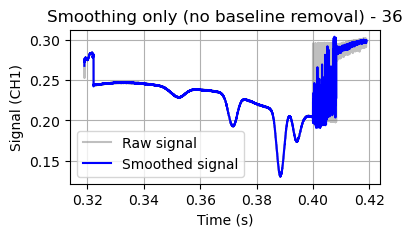

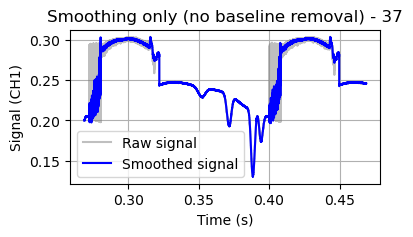

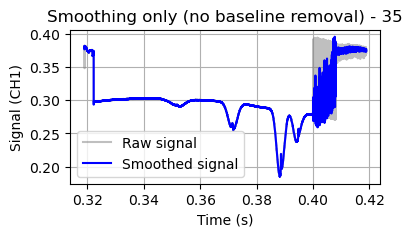

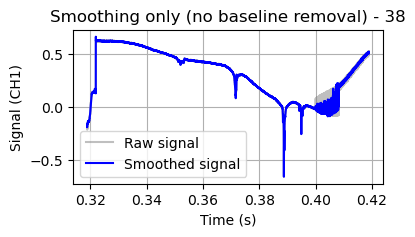

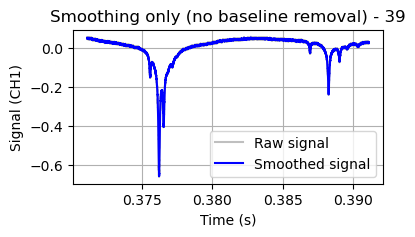

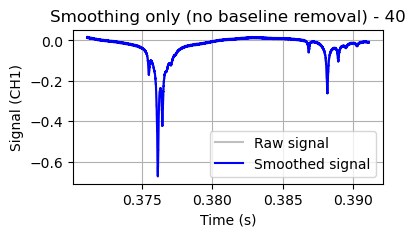

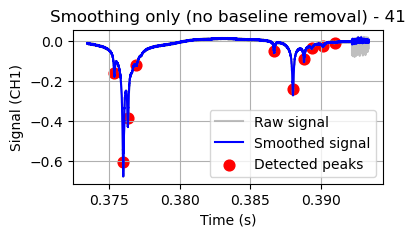

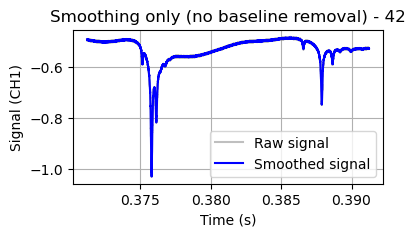

In [124]:
for i in [36,37,35,38,39,40,41,42]:
    plot_smoothed_signal(i)

Max point: 0.3831462 0.01078597555035984 0.7341576588460006
Min point: 0.3880268 -0.2408329309370876 0.6795106837891742


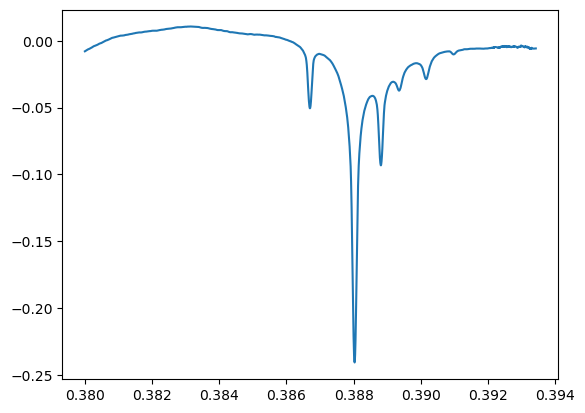

In [19]:
t, y, y_smooth,f, f_smooth = load_and_smooth(41)
t_min = 0.38
t_max = 0.40

x_max, y_max, f_max = find_max_in_range(t, y_smooth,f_smooth, t_min, t_max)
x_min, y_min, f_min = find_min_in_range(t, y_smooth,f_smooth, t_min, t_max)
print("Max point:", x_max, y_max, f_max)
print("Min point:", x_min, y_min, f_min)


mask = (t >= t_min) & (t <= t_max)

t_sel = t[mask]
y_sel = y_smooth[mask]
plt.plot(t_sel,y_sel)
data41_T1 = [0.3753576, 0.3759862, 0.3763094, 0.3769082]
data41_11 = [-0.16011896809768647, -0.6042796851057012, -0.38724909099684934, -0.12374176143111046]
data41_21 = [0.8196752774634963, 0.8138508441244201, 0.8088841149014255, 0.8028361919697905]

data41_T2 = [ 0.3866972, 0.3880268, 0.3888092, 0.3893496, 0.3901556, 0.3909764]
data41_12 = [-0.05048662215351778,  -0.2408329309370876, -0.09320802494957436, -0.03726804368028681, -0.02865581124539148, -0.010143825090629614]
data41_22 = [0.6955279375956299,  0.6795106837891742, 0.6715009129710133, 0.665594029744544, 0.6581367734061861, 0.6478125839733568]


data41_T = data41_T1+ data41_T2
data41_1 = data41_11 + data41_12
data41_2 = data41_21 + data41_22

In [20]:
from scipy.signal import savgol_filter, find_peaks

# -----------------------------
# 1. Savitzky-Golay (adaptive)
# -----------------------------
def adaptive_savgol(signal, frac=0.2, poly=3):
    n = len(signal)

    if n < 10:
        return signal

    win = int(n * frac)

    if win % 2 == 0:
        win += 1

    if win < poly + 2:
        win = poly + 3

    if win >= n:
        win = n - 1
        if win % 2 == 0:
            win -= 1

    return savgol_filter(signal, win, poly)


# -----------------------------
# 2. sweep 추출
# -----------------------------
def extract_one_sweep(ch2, ch1):
    ch2 = np.array(ch2)
    ch1 = np.array(ch1)

    if len(ch2) < 20:
        return None, None

    diff = np.diff(ch2)

    # reset (급락) 찾기
    threshold = -0.5 * np.max(np.abs(diff))
    reset_idx = np.where(diff < threshold)[0]

    if len(reset_idx) < 1:
        # sweep 분리 못하면 전체 사용
        return ch2, ch1

    start = reset_idx[0] + 1
    end = reset_idx[1] if len(reset_idx) > 1 else len(ch2)

    return ch2[start:end], ch1[start:end]


# -----------------------------
# 3. peak 추출
# -----------------------------
def extract_peaks(ch2, ch1):

    freq, signal = extract_one_sweep(ch2, ch1)
    if freq is None or len(freq) < 20:
        return None

    # frequency normalize
    freq = (freq - freq.min()) / (freq.max() - freq.min())

    # background 제거
    background = adaptive_savgol(signal, frac=0.3)
    signal = signal - background

    # smoothing
    smooth = adaptive_savgol(signal, frac=0.1)

    # dip 찾기
    inv = -smooth

    peaks, props = find_peaks(
        inv,
        height=np.std(inv) * 0.5,   # adaptive threshold
        distance=len(inv) // 20     # 데이터 길이에 맞게
    )

    if len(peaks) == 0:
        return None

    peak_freq = freq[peaks]

    return peak_freq


# -----------------------------
# 4. spacing 계산
# -----------------------------
def get_spacing(peaks):
    if peaks is None or len(peaks) < 2:
        return None
    return np.diff(peaks)


# -----------------------------
# 5. crossover 판별 (기본)
# -----------------------------
def classify_peaks(peaks):

    if peaks is None:
        return None

    labels = []

    for i in range(len(peaks)):
        is_crossover = False

        for j in range(len(peaks)):
            for k in range(len(peaks)):
                if j < k and j != i and k != i:
                    mid = (peaks[j] + peaks[k]) / 2
                    if abs(peaks[i] - mid) < 0.02:
                        is_crossover = True

        labels.append("crossover" if is_crossover else "real")

    return labels


# -----------------------------
# 6. 전체 실행
# -----------------------------
all_results = {}

for i in range(0, 8):

    peaks = extract_peaks(CH2[i], CH1[i])

    if peaks is None:
        print(f"{i}: peak 없음 / 데이터 부족")
        continue

    spacing = get_spacing(peaks)
    labels = classify_peaks(peaks)

    all_results[i] = {
        "peaks": peaks,
        "spacing": spacing,
        "type": labels
    }

    print(f"\n=== Data {i} ===")
    print("peaks:", peaks)
    print("spacing:", spacing)
    print("type:", labels)

0: peak 없음 / 데이터 부족

=== Data 1 ===
peaks: [0.67533463 0.80612103 0.59913553 0.89215003 0.75383436 0.35401562
 0.586029   0.49672337 0.82787228]
spacing: [ 0.13078639 -0.2069855   0.2930145  -0.13831567 -0.39981874  0.23201339
 -0.08930563  0.33114891]
type: ['crossover', 'crossover', 'crossover', 'real', 'crossover', 'real', 'crossover', 'crossover', 'crossover']
2: peak 없음 / 데이터 부족

=== Data 3 ===
peaks: [0.56713969 0.43440487 0.57766194 0.86128005 0.4434791  0.68481514
 0.87788397 0.3363259  0.70441162]
spacing: [-0.13273482  0.14325707  0.28361811 -0.41780095  0.24133604  0.19306883
 -0.54155807  0.36808572]
type: ['crossover', 'crossover', 'crossover', 'real', 'crossover', 'real', 'real', 'real', 'crossover']

=== Data 4 ===
peaks: [0.53665624 0.49590225 0.57510058 0.33877217 0.66934883 0.58210401
 0.65541648]
spacing: [-0.04075399  0.07919833 -0.23632842  0.33057667 -0.08724482  0.07331247]
type: ['crossover', 'crossover', 'crossover', 'real', 'real', 'crossover', 'real']

=== Da

In [ ]:
value = {}
for i in range(44,87):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)
    value[i] = df.iloc[13, 1]
    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]

44
True
45
True
46
True
47
True
48
True
49
True
50
True
51
True
52
True
53
True
54
True
55
True
56
True
57
True
58
True
59
True
60
True
61
True
62
True
63
True
64
True
65
True
66
True
67
True
68
True
69
True
70
True
71
True
72
True
73
True
74
True
75
True
76
True
77
True
78
True
79
True
80
True
81
True
82
True
83
True
84
True
85
True
86
True


In [ ]:
value = {}
for i in range(44,71):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek00{i}.xlsx"
    #print(os.path.exists(path))
    #print("Reading:", path)
    meta = pd.read_excel(path, header=None)
    value[i] = meta.iloc[15, 1]
    print(value[i])
    df = pd.read_excel(path, skiprows=20)
    Time[i] = df["TIME"]
    CH1[i] = df["CH1"]
    CH2[i] = df["CH2"]


    '''vertical_position = meta.iloc[row_pos, 1]   # div 단위
vertical_scale    = meta.iloc[row_scale, 1] # V/div

offset_voltage = vertical_position * vertical_scale

CH1[i] = df["CH1"] - offset_voltage
'''

44
-3.2
45
-3.44
46
-4.7
47
-4.7
48
-4.7
49
-4.7
50
-4.7
51
-4.7
52
-4.7
53
-4.7
54
-4.7
55
-4.7
56
-4.7
57
-4.7
58
-4.7
59
-4.7
60
-4.7
61
-4.7
62
-4.7
63
-4.7
64
-4.7
65
-4.7
66
-2.48
67
-2.48
68
-2.48
69
-2.48
70
-2.48


In [ ]:
#for i in range(44,71):
#CH1[i] = df["CH1"] + value[i]


SyntaxError: incomplete input (2478101186.py, line 2)

c:\Users\ainch\anaconda3\envs\ppp\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\ainch\anaconda3\envs\ppp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


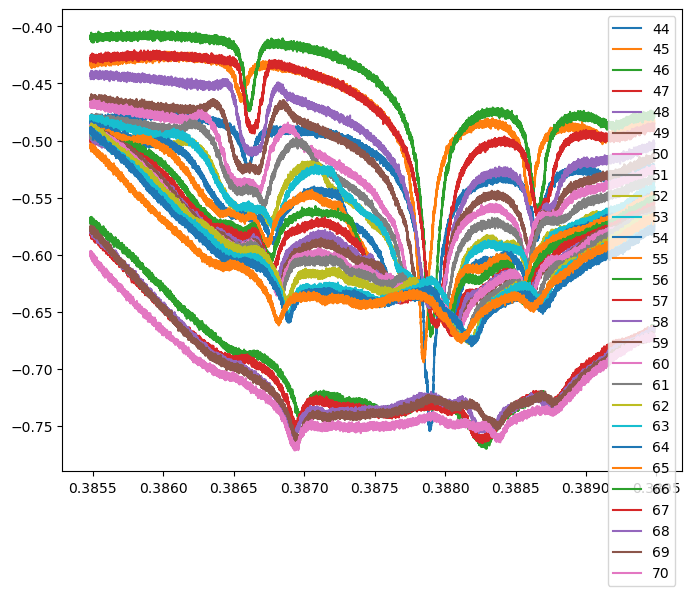

In [855]:
plt.figure(figsize=(8,6))
for i in range(44,71):  
    plt.plot(Time[i],CH1[i], label=f"{i}")
plt.legend()

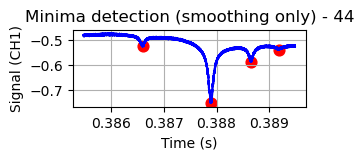

0.386607, -0.525989, -0.526148, 0.719006, 0.728188
0.387891, -0.754131, -0.753953, 0.708478, 0.716313
0.388656, -0.587758, -0.587766, 0.698456, 0.693969
0.389182, -0.538728, -0.538383, 0.683946, 0.680375


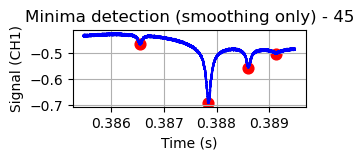

0.386551, -0.465561, -0.466195, 0.721089, 0.720219
0.387848, -0.694391, -0.694336, 0.709103, 0.710688
0.388602, -0.556213, -0.556352, 0.698344, 0.697094
0.389117, -0.503083, -0.503227, 0.685345, 0.694438


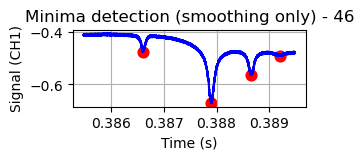

0.386609, -0.473808, -0.474008, 0.727652, 0.731000
0.387898, -0.671648, -0.671273, 0.702206, 0.697875
0.388652, -0.563931, -0.563969, 0.701729, 0.701938
0.389208, -0.491725, -0.491859, 0.694720, 0.700375


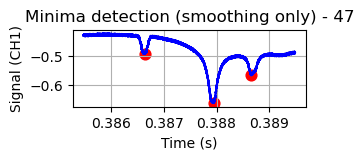

0.386647, -0.493794, -0.493805, 0.716156, 0.718656
0.387944, -0.663770, -0.664086, 0.701774, 0.696313
0.388654, -0.567186, -0.567266, 0.688753, 0.686469


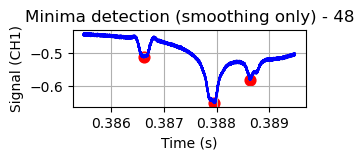

0.386631, -0.513479, -0.513586, 0.718976, 0.717406
0.387955, -0.654384, -0.654398, 0.701640, 0.705531
0.388632, -0.583153, -0.583383, 0.690420, 0.696313


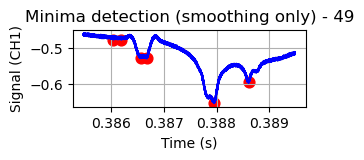

0.386050, -0.477073, -0.477234, 0.731476, 0.730219
0.386201, -0.477305, -0.477375, 0.726178, 0.723031
0.386564, -0.528986, -0.528805, 0.715360, 0.715844
0.386677, -0.529380, -0.529539, 0.723136, 0.720219
0.387953, -0.653846, -0.653883, 0.701127, 0.703188
0.388608, -0.596450, -0.596219, 0.700561, 0.701469


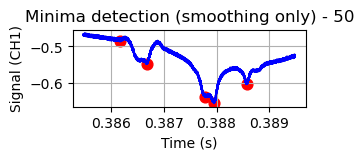

0.386180, -0.486262, -0.486328, 0.720799, 0.717094
0.386677, -0.547484, -0.547469, 0.717064, 0.716313
0.387790, -0.637658, -0.638359, 0.703441, 0.701469
0.387951, -0.653778, -0.653883, 0.701357, 0.705844
0.388578, -0.602274, -0.602086, 0.694415, 0.695531


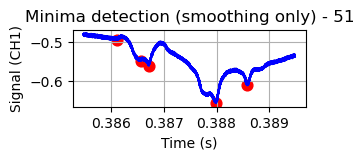

0.386108, -0.493639, -0.493727, 0.726610, 0.721781
0.386562, -0.548052, -0.547945, 0.715494, 0.717875
0.386718, -0.560735, -0.561258, 0.718865, 0.718969
0.387987, -0.657147, -0.657367, 0.703761, 0.705531
0.388580, -0.610882, -0.610844, 0.692912, 0.693188


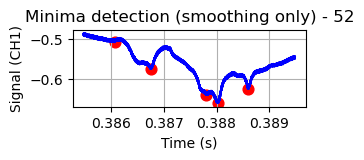

0.386075, -0.507960, -0.508016, 0.725182, 0.725375
0.386764, -0.574958, -0.575266, 0.719415, 0.715063
0.387802, -0.639871, -0.639438, 0.699259, 0.688344
0.388025, -0.660016, -0.659555, 0.699118, 0.699906
0.388603, -0.624890, -0.624969, 0.694468, 0.694438


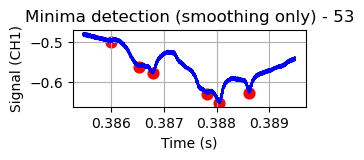

0.385995, -0.499577, -0.499359, 0.725509, 0.723344
0.386531, -0.562611, -0.562695, 0.724445, 0.723031
0.386798, -0.578440, -0.578945, 0.724326, 0.732563
0.387822, -0.630438, -0.630664, 0.704185, 0.706625
0.388055, -0.652791, -0.653125, 0.710279, 0.705844
0.388612, -0.627033, -0.626602, 0.693917, 0.689906


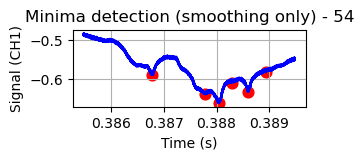

0.386784, -0.591090, -0.591242, 0.713507, 0.721469
0.387787, -0.640679, -0.640828, 0.698984, 0.698344
0.388038, -0.663542, -0.663570, 0.702451, 0.703188
0.388289, -0.611192, -0.611500, 0.699215, 0.692719
0.388596, -0.634580, -0.634680, 0.694155, 0.695531
0.388931, -0.584294, -0.584578, 0.695554, 0.684438


In [ ]:
def plot_smoothed_with_peaks3(i, ):
    window_length=7
    polyorder=3
    prom_scale=0.2
    dist_scale=250
    # ----------------------------
    # 1) Load data
    # ----------------------------
    t = Time[i]
    y = CH1[i]
    f = CH2[i]

    # ----------------------------
    # 2) Smoothing
    # ----------------------------
    if window_length % 2 == 0:
        window_length += 1

    y_s = savgol_filter(y, window_length, polyorder)
    f_s = savgol_filter(f, window_length, polyorder)

    # ----------------------------
    # 3) Minima detection
    # ----------------------------
    prom = np.std(y_s) * prom_scale
    dist = len(y) // dist_scale

    peaks, _ = find_peaks(-y_s, prominence=prom, distance=dist)

    # ----------------------------
    # 4) Plot
    # ----------------------------
    plt.figure(figsize=(3,1))
    plt.plot(t, y, color='gray', alpha=0.4, label="Raw")
    plt.plot(t, y_s, color='blue', label=f"Smoothed (win={window_length})")
    plt.scatter(t[peaks], y_s[peaks], c='red', s=60, label="Detected minima")
    plt.title(f"Minima detection (smoothing only) - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    #plt.legend()
    plt.show()

    # ----------------------------
    # 5) Create dynamic list names
    # ----------------------------
    globals()[f"data{i}_T"] = []
    globals()[f"data{i}_1"] = []
    globals()[f"data{i}_y"] = []
    globals()[f"data{i}_2"] = []
    globals()[f"data{i}_f"] = []

    # ----------------------------
    # 6) Print + Save numeric result
    # ----------------------------
    #print(f"\n▶ FILE: {i}")
    #print(f"window_length = {window_length}, polyorder = {polyorder}")
    #print(f"Detected minima: {len(peaks)}")

    #print("\nt, y_s, y, f_s, f")
    for idx in peaks:
        # print
        print(f"{t[idx]:.6f}, {y_s[idx]:.6f}, {y[idx]:.6f}, {f_s[idx]:.6f}, {f[idx]:.6f}")

        # save into dynamically created lists
        globals()[f"data{i}_T"].append(float(t[idx]))
        globals()[f"data{i}_1"].append(float(y_s[idx]))
        globals()[f"data{i}_y"].append(float(y[idx]))
        globals()[f"data{i}_2"].append(float(f_s[idx]))
        globals()[f"data{i}_f"].append(float(f[idx]))
for i in range(44,55):
    plot_smoothed_with_peaks3(i) # 약한 smoothing → 작은 peak 민감하게 잡음



In [248]:
for i in range(50,55):
    print(f"data{i}_T = {globals()[f'data{i}_T']}")
    print(f"data{i}_1 = {globals()[f'data{i}_1']}")
    print(f"data{i}_y = {globals()[f'data{i}_y']}")
    print(f"data{i}_2 = {globals()[f'data{i}_2']}")
    print(f"data{i}_f = {globals()[f'data{i}_f']}")
    print()

data50_T = [0.38617972, 0.38667692, 0.3877898, 0.38795144, 0.38857836]
data50_1 = [-0.4862618571428575, -0.5474843809523813, -0.6376581428571434, -0.6537781428571434, -0.602274428571429]
data50_y = [-0.486328, -0.547469, -0.638359, -0.653883, -0.602086]
data50_2 = [0.7207990476190481, 0.7170642380952387, 0.703440571428572, 0.7013573809523814, 0.6944150952380959]
data50_f = [0.717094, 0.716313, 0.701469, 0.705844, 0.695531]

data51_T = [0.38610764, 0.386562, 0.38671832, 0.38798696, 0.38858004]
data51_1 = [-0.4936386190476194, -0.5480518571428576, -0.5607354761904766, -0.6571472857142863, -0.6108821428571434]
data51_y = [-0.493727, -0.547945, -0.561258, -0.657367, -0.610844]
data51_2 = [0.7266100952380958, 0.7154939523809529, 0.7188647142857147, 0.703760571428572, 0.6929123333333338]
data51_f = [0.721781, 0.717875, 0.718969, 0.705531, 0.693188]

data52_T = [0.38607484, 0.38676352, 0.38780172, 0.38802492, 0.38860316]
data52_1 = [-0.5079601428571433, -0.5749580476190481, -0.639871095238095

In [829]:
data44_T = [0.38660712, 0.38789108, 0.38865588, 0.38918216]
data44_1 = [-0.5259889523809529, -0.754130571428572, -0.5877579047619054, -0.5387282380952385]
data44_y = [-0.526148, -0.753953, -0.587766, -0.538383]
data44_2 = [0.7190062857142863, 0.7084779047619054, 0.6984555238095242, 0.6839464285714292]
data44_f = [0.728188, 0.716313, 0.693969, 0.680375]

data45_T = [0.38655076, 0.3878476, 0.38860232, 0.38911708]
data45_1 = [-0.46556085714285755, -0.6943906190476195, -0.5562130000000005, -0.5030832380952385]
data45_y = [-0.466195, -0.694336, -0.556352, -0.503227]
data45_2 = [0.7210893809523815, 0.7091030000000005, 0.6983440000000005, 0.6853454285714291]
data45_f = [0.720219, 0.710688, 0.697094, 0.694438]

data46_T = [0.38660884, 0.38789764, 0.38865212, 0.3892076]
data46_1 = [-0.4738082380952385, -0.6716478571428577, -0.5639314285714291, -0.4917250000000004]
data46_y = [-0.474008, -0.671273, -0.563969, -0.491859]
data46_2 = [0.7276519047619052, 0.7022056190476196, 0.7017293809523815, 0.6947202380952386]
data46_f = [0.731, 0.697875, 0.701938, 0.700375]

data47_T = [0.38664696, 0.387944, 0.38865408]
data47_1 = [-0.4937943333333337, -0.6637700000000005, -0.567186047619048]
data47_y = [-0.493805, -0.664086, -0.567266]
data47_2 = [0.7161563809523814, 0.7017740000000006, 0.6887531428571435]
data47_f = [0.718656, 0.696313, 0.686469]

data48_T = [0.38663124, 0.38795496, 0.38863236, 0.38874496]
data48_1 = [-0.5134785714285719, -0.6543841428571433, -0.5831527142857147, -0.5597261011165772]
data48_y = [-0.513586, -0.654398, -0.583383, -0.560188]
data48_2 = [0.7189762380952387, 0.7016398571428577, 0.6904200000000005, 0.6942746428133587]
data48_f = [0.717406, 0.705531, 0.696313, 0.689594]

data49_T = [ 0.38656392, 0.38667656,  0.38785004,0.38795332, 0.3886082, 0.3887454]
data49_1 = [-0.5289861904761908, -0.5293800952380957,-0.6378553809126623,  -0.653845571428572, -0.596450190476191, -0.565852090621777]
data49_y = [ -0.528805, -0.529539, -0.63693, -0.653883, -0.596219, -0.566156]
data49_2 = [ 0.7153603333333338, 0.7231355238095245,0.7058017121857376,  0.7011268571428577, 0.7005612380952386, 0.6976297602882213]
data49_f = [0.715844, 0.720219, 0.707875, 0.703188, 0.701469, 0.693188]

data50_T = [0.38655252, 0.38667692, 0.3877898, 0.38795144, 0.38857836,0.3887496 ]
data50_1 = [-0.5373067583820633, -0.5474843809523813, -0.6376581428571434, -0.6537781428571434, -0.602274428571429,-0.5660006796160323]
data50_y = [-0.537898 , -0.547469, -0.638359, -0.653883, -0.602086,-0.565875]
data50_2 = [ 0.7187909534555719, 0.7170642380952387, 0.703440571428572, 0.7013573809523814, 0.6944150952380959,0.69591674739827]
data50_f = [ 0.724281, 0.716313, 0.701469, 0.705844, 0.695531,0.696781]

data51_T = [ 0.386562, 0.38671832,0.38781396, 0.38798696, 0.38858004,0.3887998 ]
data51_1 = [ -0.5480518571428576, -0.5607354761904766,-0.6353456479503614, -0.6571472857142863, -0.6108821428571434, -0.5707453832778344]
data51_y = [-0.547945, -0.561258, -0.634523, -0.657367, -0.610844,-0.569578 ]
data51_2 = [ 0.7154939523809529, 0.7188647142857147, 0.7067053474116148 , 0.703760571428572, 0.6929123333333338, 0.6974097495521971]
data51_f = [ 0.717875, 0.718969, 0.707875, 0.705531, 0.693188,0.695531]

data52_T = [0.38654508, 0.38676352, 0.38780172, 0.38802492, 0.38860316]
data52_1 = [-0.5603631060817852, -0.5749580476190481, -0.6398710952380957, -0.660016190476191, -0.6248902857142862]
data52_y = [-0.559492, -0.575266, -0.639438, -0.659555, -0.624969]
data52_2 = [0.7227708687442361, 0.7194152857142864, 0.6992593333333339, 0.6991178571428578, 0.6944675238095244]
data52_f = [0.721, 0.715063, 0.688344, 0.699906, 0.694438]

data53_T = [ 0.38653052, 0.3867978, 0.3878216, 0.388055, 0.38861208]
data53_1 = [-0.5626111904761909, -0.5784395714285719, -0.6304381904761911, -0.6527912857142862, -0.6270328571428576]
data53_y = [-0.562695, -0.578945, -0.630664, -0.653125, -0.626602]
data53_2 = [ 0.7244448571428577, 0.7243261428571434, 0.7041849047619053, 0.7102786190476196, 0.6939166190476196]
data53_f = [ 0.723031, 0.732563, 0.706625, 0.705844, 0.689906]

data54_T = [0.38651324, 0.38662796, 0.38678444, 0.3877866, 0.38803832, 0.38859624]
data54_1 = [-0.5661199242958426, -0.5688495126327402, -0.5910898571428576, -0.6406788571428577, -0.6635421428571433, -0.6345796190476196]
data54_y = [-0.56707, -0.569219, -0.591242, -0.640828, -0.66357, -0.63468]
data54_2 = [0.7240093012038878, 0.71870335619828, 0.7135074761904767, 0.6989840476190481, 0.7024510476190482, 0.6941548571428577]
data54_f = [0.72975, 0.714281, 0.721469, 0.698344, 0.703188,  0.695531]

data55_T = [0.38641308, 0.3865754, 0.3867388, 0.3877288, 0.38800188,0.3882372, 0.38853956]
data55_1 = [-0.5645424777410362, -0.5682628696559919, -0.5929126666666671, -0.6366606190476196, -0.6617370000000005, -0.6135443186822321,-0.6382633809523814]
data55_y = [-0.564344, -0.567133, -0.592938, -0.637031, -0.661625,-0.611977, -0.638305]
data55_2 = [0.7165423861490271, 0.7159692564699266, 0.7210447142857148, 0.7044230000000006, 0.6966177619047624,0.7010850344307294, 0.7020640476190482]
data55_f = [0.707875, 0.72225, 0.714594, 0.700688, 0.699125, 0.703188, 0.701469]

data56_T = [0.38640788, 0.38657404, 0.38675616, 0.38767676, 0.38801912, 0.38821016, 0.38855652]
data56_1 = [-0.5741059560133044 , -0.5828977142857148, -0.6060999047619053, -0.6353454285714291, -0.662347190476191, -0.6256834761904767, -0.6430023809523815]
data56_y = [-0.574055, -0.58257, -0.606445, -0.63568, -0.662281, -0.62543, -0.643258]
data56_2 = [0.7211932757650324, 0.7218781904761911, 0.7155090952380957, 0.7063944285714292, 0.6993782380952387, 0.6976590952380957, 0.6937455238095245]
data56_f = [0.726625, 0.723813, 0.718969, 0.711, 0.699594, 0.708656, 0.699906]

data57_T = [0.38639472, 0.38656728, 0.38677784, 0.38769408, 0.38804628, 0.38820648, 0.38857684]
data57_1 = [-0.5772593547061625, -0.58792980952381, -0.6146880952380958, -0.6426216666666671, -0.6710217142857148, -0.6342039297965493, -0.6448316666666671]
data57_y = [-0.579227, -0.58782, -0.614742, -0.642219, -0.67125,-0.634102,  -0.645109]
data57_2 = [0.7224798655032285, 0.718820333333334, 0.7111266666666672, 0.7001965238095244, 0.6978897619047624,0.6999453168040987,  0.6937160476190481]
data57_f = [0.726625, 0.720219, 0.705844, 0.698344, 0.695531,0.69475, 0.698813]

data58_T = [0.38654292, 0.38681076, 0.3874406, 0.38767804, 0.38806948, 0.38859492]
data58_1 = [-0.5950287142857147, -0.6259085714285719, -0.6079027142857147, -0.6421063809523814, -0.6673127619047624, -0.6436306190476195]
data58_y = [-0.595164, -0.626281, -0.607977, -0.642242, -0.667453, -0.643836]
data58_2 = [0.7138501428571433, 0.7221908095238101, 0.7072427142857148, 0.7094004761904767, 0.7126813333333339, 0.7006356190476197]
data58_f = [0.723344, 0.727719, 0.710219, 0.710219, 0.713031, 0.697875]

data59_T = [0.38658044, 0.38681068, 0.38772068, 0.3880938, 0.3886014]
data59_1 = [-0.5972267142857147, -0.6321896190476195, -0.6363549523809529, -0.6679676666666672,  -0.6443060476190481]
data59_y = [-0.597078, -0.631758, -0.636594, -0.668211, -0.644711]
data59_2 = [0.7196685238095244, 0.7200553333333339, 0.7133739047619052, 0.7031205238095244,  0.6963945714285721]
data59_f = [0.719438, 0.721, 0.710688, 0.70225, 0.707875]

data60_T = [ 0.38655524, 0.38682064, 0.3873576, 0.38755372,  0.38809176, 0.3886056]
data60_1 = [-0.5972717142857147, -0.6361855714285719, -0.6171763809523815, -0.6253459523809529,  -0.6667735238095245, -0.6406051428571433]
data60_y = [ -0.59725, -0.636133, -0.61707, -0.625391, -0.66725, -0.640594]
data60_2 = [ 0.7166103809523816, 0.7155090476190482, 0.7117291904761911, 0.7034927619047624,  0.705999952380953, 0.6941623809523816]
data60_f = [ 0.71225, 0.716313, 0.709906, 0.697563,  0.705531, 0.693969]

data61_T = [0.38653828, 0.38683484, 0.38756468, 0.38813272, 0.388634]
data61_1 = [ -0.5974584285714291, -0.6369067142857148, -0.6298253809523815, -0.6744421904761909, -0.6451218571428576]
data61_y = [-0.59793, -0.637172, -0.629984, -0.675414, -0.645563]
data61_2 = [ 0.7199437142857148, 0.7131354761904768, 0.7144896190476197, 0.696342428571429, 0.692793190476191]
data61_f = [ 0.716625, 0.716625, 0.7035, 0.692719, 0.696781]

data62_T = [0.38687984, 0.38762016, 0.38819556, 0.38867016]
data62_1 = [-0.6438849523809529, -0.637886190476191, -0.679568571428572, -0.645723190476191]
data62_y = [-0.644234, -0.638047, -0.679531, -0.645523]
data62_2 = [0.7167517142857148, 0.7042887619047624, 0.7041546666666674, 0.6963272380952386]
data62_f = [0.715063, 0.703969, 0.714281, 0.696781]

data63_T = [0.38688688, 0.38756056, 0.38820176, 0.38867424]
data63_1 = [-0.6556565714285719, -0.6433438571428576, -0.6782473333333339, -0.6436882857142863]
data63_y = [-0.656508, -0.643234, -0.678359, -0.643711]
data63_2 = [0.7173395714285721, 0.7039391428571434, 0.7020714761904767, 0.6937978571428576]
data63_f = [0.7135, 0.706313, 0.70225, 0.69475]

data64_T = [ 0.38689396, 0.38748236, 0.38818708, 0.3886938]
data64_1 = [ -0.6592130000000005, -0.645963571428572, -0.6798714285714291, -0.6513979523809528]
data64_y = [ -0.659672, -0.646344, -0.679891, -0.651992]
data64_2 = [ 0.7281801428571435, 0.7144600000000005, 0.7078455714285721, 0.6963052857142862]
data64_f = [0.718656, 0.719438, 0.710219, 0.691156]

data65_T = [0.38643236, 0.38682,  0.3871474, 0.38743628, 0.38811532,0.3886266]
data65_1 = [ -0.6106714995104778, -0.6616829523809529,  -0.6441248571428577,  -0.6471765238095244, -0.6769466666666673, -0.6500542380952385]
data65_y = [ -0.61043, -0.662141, -0.644547, -0.647016, -0.677641,-0.650203]
data65_2 = [0.7212448596646742, 0.7125703333333339,  0.711692190476191, 0.7102784761904768,  0.7096830952380958, 0.6945196666666673]
data65_f = [ 0.719906, 0.712719, 0.707563, 0.7135, 0.714281, 0.696313]

data66_T = [0.38697872, 0.38758976, 0.38829432, 0.38877424]
data66_1 = [-0.745946190476191, -0.7414368571428578, -0.7696945714285721, -0.7369807619047625]
data66_y = [-0.745938, -0.741742, -0.769758, -0.737148]
data66_2 = [0.7123618095238102, 0.7018930952380958, 0.6983660476190481, 0.6991996666666671]
data66_f = [0.715844, 0.688813, 0.69475, 0.70225]

data67_T = [ 0.38694264,  0.38758992, 0.38826816, 0.38875088]
data67_1 = [ -0.7524634761904769, -0.7399566021171728, -0.7647485238095245, -0.7347666666666672]
data67_y = [-0.752164, -0.73993, -0.764367, -0.734734]
data67_2 = [ 0.7141178095238101, 0.7008004232792718, 0.6938722857142863, 0.6942667142857148]
data67_f = [ 0.707875, 0.705531, 0.691938, 0.698344]

data68_T = [0.38692004, 0.38808988, 0.38824028, 0.3887382]
data68_1 = [-0.7643143809523816,  -0.7350022857142863, -0.7563716190476196, -0.7362773333333339]
data68_y = [-0.763984,  -0.735039, -0.755867, -0.736883]
data68_2 = [0.7167367142857148, 0.7053304761904767, 0.7071684761904767, 0.6907695238095244]
data68_f = [0.719438, 0.707563, 0.707563, 0.6935]

data69_T = [0.38695632, 0.38718376, 0.3880522, 0.38836716, 0.38879276]
data69_1 = [-0.7661029047619055, -0.7460115238095244, -0.7373093809523815, -0.753104333333334, -0.733815952380953]
data69_y = [-0.766375, -0.746039, -0.737484, -0.753, -0.733586]
data69_2 = [0.7126890952380958, 0.7074436190476197, 0.7009185238095246, 0.6993781428571435, 0.6921832380952386]
data69_f = [0.717875, 0.710688, 0.703188, 0.693188, 0.691156]

data70_T = [0.38695812,0.38806308, 0.38821864, 0.388365,0.38876716]
data70_1 = [-0.771262952380953, -0.7495119340425761, -0.7555608095238101, -0.7639490476190482,-0.7383711141956301]
data70_y = [-0.771406, -0.748742, -0.755711, -0.763711,-0.736211,]
data70_2 = [0.7100029523809529, 0.7017151812845944, 0.6989243333333339, 0.6947054285714291,0.6904706861423996]
data70_f = [0.708656, 0.697094, 0.699125, 0.690375,0.689125]

data71_T = [0.38675492, 0.38805748, 0.38878088]
data71_1 = [-0.6284154285714292, -0.808632571428572, -0.7193711428571434]
data71_y = [-0.628586, -0.808977, -0.719617]
data71_2 = [0.7171978571428579, 0.704117952380953, 0.6968854761904768]
data71_f = [0.71225, 0.703188, 0.699125]

data72_T = [0.3867332, 0.38805344, 0.38876044]
data72_1 = [-0.6320249523809529, -0.8085963333333339, -0.7313383333333339]
data72_y = [-0.632188, -0.808797, -0.731156]
data72_2 = [0.7130833809523816, 0.6851519047619054, 0.6972206190476196]
data72_f = [0.717406, 0.672094, 0.694438]

data73_T = [0.38674924, 0.38810124, 0.38877092,0.3888628]
data73_1 = [-0.6491206666666672, -0.8187634285714293, -0.7458290000000005,-0.7193137203599668]
data73_y = [-0.649359, -0.819039, -0.745227,-0.718859]
data73_2 = [0.7207991428571434, 0.6993035238095244, 0.6915808571428577,0.689729221846043]
data73_f = [0.721469, 0.688031, 0.687563, 0.691156]

data74_T = [0.38671568,0.38798512, 0.3880702, 0.38873952,0.38885312]
data74_1 = [-0.6671054761904767,-0.8087524405513672, -0.8220337619047624, -0.7598012380952387,-0.7299308200399203]
data74_y = [-0.667445,-0.807266, -0.822164, -0.759633,-0.732727]
data74_2 = [0.7184035714285719,0.7010700313913081, 0.7030163333333339, 0.6863943809523816,0.696746353244485]
data74_f = [0.714594,0.704281, 0.697875, 0.686,0.698813]

data75_T = [0.38675152,0.38684804, 0.3880316, 0.38812592, 0.38879036,0.38892308]
data75_1 = [-0.6973034761904768, -0.6914878775136506,-0.8361863613417054,-0.8515823809523816, -0.7886751904761912,-0.7554592594890416]
data75_y = [-0.697789, -0.689375,-0.836391, -0.851656, -0.788305,-0.753703]
data75_2 = [0.7194006666666672, 0.7164050545303916,0.7052358701725168, 0.7007992857142862, 0.6889316190476196,0.6902410704830513]
data75_f = [0.715063, 0.709906,0.701938, 0.698344, 0.687563,0.699906]

data76_T = [0.38672396, 0.38683208, 0.38799528, 0.38811612, 0.38876496, 0.388915]
data76_1 = [-0.7100271320295098, -0.7133479523809529, -0.8381048163908754, -0.8550150952380959, -0.8019393809523816,-0.7665321898021952]
data76_y = [-0.709375, -0.713055, -0.837336, -0.854859, -0.801992,-0.764273]
data76_2 = [0.7183437572616611, 0.7103974761904768, 0.6996663935202928, 0.6958440952380958, 0.7023244761904768,0.6914476674016565]
data76_f = [ 0.717094, 0.710219, 0.703188, 0.701938, 0.706625,0.697563]

data77_T = [0.38673068, 0.38687204, 0.38799892, 0.38813392, 0.3887712,0.38893116]
data77_1 = [-0.7387722992520733, -0.7436536666666672, -0.8712962991780345, -0.8904878095238102, -0.8411180952380959, -0.8048888929430116]
data77_y = [-0.737508, -0.743656, -0.871914, -0.890477, -0.841711,-0.805953]
data77_2 = [0.7171612229833583, 0.7137830000000005,0.7049973212990518,  0.6997201428571433, 0.6948098571428578,0.690658928154784 ]
data77_f = [0.707094, 0.705844, 0.694438, 0.695531, 0.691625,0.682406]

data78_T = [0.3867446, 0.38688316,0.38801524 ,  0.38815452, 0.3887878,0.38897804]
data78_1 = [-0.7642149241528116 , -0.770714952380953, -0.8882590316417489, -0.9126898571428579, -0.873775714285715,  -0.8354557373368188]
data78_y = [-0.762734, -0.770938,  -0.885859 , -0.912828, -0.873648,-0.835023]
data78_2 = [0.7169994867744085 , 0.714869333333334,0.7034712859695033,  0.7154718571428578, 0.6910220952380957,0.6871195938453868 ]
data78_f = [0.721, 0.707563,0.700688,  0.718656, 0.691156, 0.686]

data79_T = [0.3867836, 0.3869202, 0.3880434, 0.3881988, 0.38881228, 0.38900976]
data79_1 = [-0.7690746890967421, -0.7784105714285721,  -0.895462423745605, -0.9183509047619055, -0.8803354761904769, -0.837220454388424 ]
data79_y = [-0.766844 , -0.778563, -0.896211,  -0.918695, -0.880352,-0.837719 ]
data79_2 = [0.7151900051159982, 0.7152709523809531,0.6961611403156633 ,  0.6943110000000006, 0.6927113333333339, 0.6882293708169676]
data79_f = [0.716625, 0.712719, 0.691625, 0.689125, 0.695219,0.684438]

data80_T = [0.3867414, 0.3869082,  0.38802228, 0.38817236, 0.38878048,0.38900032]
data80_1 = [-0.7786238926174645, -0.7888850476190483,-0.8919648759062186 ,  -0.9176512380952389, -0.8861450000000008, -0.8464126380761262 ]
data80_y = [ -0.777188, -0.788406, -0.891594, -0.917289, -0.885906,-0.846469]
data80_2 = [0.715796745317759, 0.7087305238095244, 0.7050540324104265 ,  0.6967888571428578, 0.6912233333333339,0.6967648379995726 ]
data80_f = [ 0.709125, 0.709906,0.707094,  0.697563, 0.692719,0.706313]

data81_T = [0.38670948, 0.3868814, 0.38797092, 0.38813908, 0.38873792]
data81_1 = [-0.7864905423382815, -0.8006580000000008, -0.9049353391496898, -0.9304140000000007, -0.8950065714285722]
data81_y = [-0.785445, -0.800945,-0.903594,  -0.930617, -0.89518]
data81_2 = [0.7210640703942521 , 0.713351571428572,0.7048933332957306 ,  0.7037532857142863, 0.6910520952380959]
data81_f = [0.720219, 0.714594,0.701469, 0.69475, 0.690375]

data82_T = [0.38671872, 0.38689184,0.387973 ,  0.38815772, 0.38874388]
data82_1 = [-0.7925098134791152, -0.8078430000000008, -0.9059698046602549, -0.9364811428571436, -0.9039527619047627]
data82_y = [-0.792984 , -0.807891, -0.906266, -0.936688, -0.903977]
data82_2 = [ 0.7168480450779464, 0.717562571428572, 0.702390316722012 ,  0.6974210952380958, 0.6886195714285721]
data82_f = [0.709438, 0.710219,0.696781,  0.696781, 0.693188]

data83_T = [0.38671932, 0.38691708, 0.3879904 ,0.38818436, 0.38876908]
data83_1 = [-0.7998025641812022, -0.8167369523809531, -0.9045570309015404, -0.936189476190477, -0.9101143809523816]
data83_y = [-0.799469, -0.816602,-0.904312 , -0.936164, -0.909961]
data83_2 = [0.715542696932082, 0.7215578571428578,  0.6992679142486204, 0.7074511904761911, 0.6879642857142862]
data83_f = [ 0.707563, 0.719906, 0.705531, 0.711938, 0.691156]

data84_T = [0.38671828, 0.3869224, 0.38800628, 0.38819264, 0.38876916]
data84_1 = [ -0.8099173704052745 , -0.8253277142857149, -0.9126427720839614, -0.9451332857142865, -0.9174876190476198]
data84_y = [-0.811289, -0.825734, -0.911078 , -0.945281, -0.917586]
data84_2 = [0.7147536328264311 , 0.7114986190476196, 0.6988117323764246 , 0.6970270952380959, 0.697622190476191]
data84_f = [ 0.713031, 0.705531,0.698344, 0.689594, 0.698344]

data85_T = [0.38674076, 0.38696524, 0.38802484, 0.38823492, 0.3888024]
data85_1 = [-0.793465681272764 ,-0.8130668095238102, -0.895670126201394, -0.9275720476190484, -0.9042559523809532]
data85_y = [-0.793898, -0.813359,  -0.894461, -0.927852, -0.904289]
data85_2 = [0.7173567358363003,  0.7094300952380959, 0.7022679028163153, 0.7002635238095245, 0.6930389047619053]
data85_f = [ 0.718969, 0.716625, 0.701469, 0.696, 0.697094]

data86_T = [0.38671492,  0.38695244, 0.3879924, 0.38821584, 0.38880272]
data86_1 = [-0.7923220704573503,  -0.8125818095238102, -0.8814937619047626, -0.9082709047619055, -0.8922516666666674]
data86_y = [-0.793625, -0.812328, -0.881906, -0.908172, -0.892492]
data86_2 = [0.715409405817568 ,  0.7126742380952387, 0.7070194285714292, 0.7010967619047626, 0.6968185238095244]
data86_f = [0.710688,  0.713031, 0.710219, 0.693188, 0.696]

<Figure size 400x300 with 0 Axes>

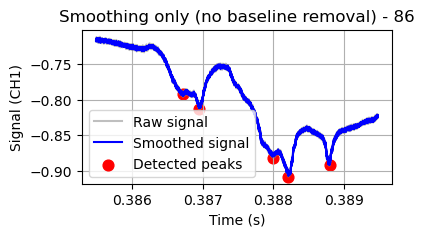

In [849]:
def plot_smoothed_signal2(i):

    # ----------------------------
    # Load data
    # ----------------------------
    
    t = Time[i]
    y = CH1[i]

    # ----------------------------
    # Smoothing only (NO baseline removal)
    # ----------------------------
    # window는 signal 길이에 따라 자동 결정 (너무 세게 안 깎이도록)
    #win = max(31, (len(y) // 200) * 2 + 1)
    win =7
    y_smooth = savgol_filter(y, win, polyorder=3)

    # ----------------------------
    # Plot
    # ----------------------------
    
    plt.plot(t, y, color='gray', alpha=0.5, label='Raw signal')
    plt.plot(t, y_smooth, color='blue', label=f'{i}')

    if f"data{i}_T" in globals() and f"data{i}_1" in globals():
        plt.scatter(globals()[f"data{i}_T"], globals()[f"data{i}_1"], c='red', s=60, label="Detected peaks")

    '''
    plt.title(f"Smoothing only (no baseline removal) - {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Signal (CH1)")
    plt.grid()
    plt.legend()
    plt.show()'''
plt.figure(figsize=(4,3))
for i in range(86,87):
    plot_smoothed_signal(i)

Min point: 0.386738 -0.5894768278186341 -0.589992 0.719937023055022 0.715375


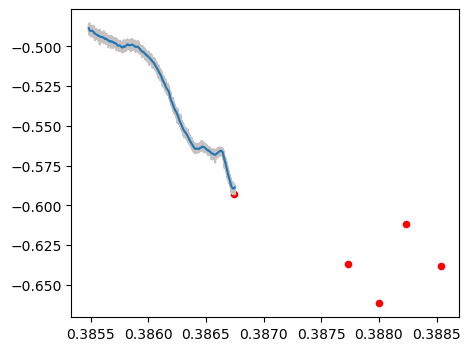

In [ ]:
k =55
t, y, y_smooth,f, f_smooth = load_and_smooth(k)
t_min = 0.38
t_max = 0.38675


#x_max, y_max, f_max = find_max_in_range(t, y_smooth,f_smooth, t_min, t_max)
x_min, y_min, ch1_min, f_min, ch2_min = find_min_in_range(t, y_smooth,y, f_smooth,f, t_min, t_max)
#print("Max point:", x_max, y_max, f_max)
print("Min point:", x_min, y_min, ch1_min, f_min, ch2_min)
mask = (t >= t_min) & (t <= t_max)
t_sel = t[mask]
y_sel = y_smooth[mask]
f_sel = f_smooth[mask]
plt.figure(figsize=(5,4))
plt.plot(t_sel, y[mask], color = "#c7c1c1")
plt.plot(t_sel,y_sel)
plt.scatter(data55_T,data55_y , marker='.', s=80, color = 'red')
#plt.figure()
#plt.plot(t_sel,f[mask], color = "#c7c1c1")
#plt.plot(t_sel, f_sel)
#plt.scatter(t_sel[::2],y_sel[::2], marker='.', s=10)
#plt.scatter(data65_T,data65_2 , marker='.', s=30, color = 'red')


#1,2가 smooth, y,f가 오리지널



<Figure size 640x480 with 0 Axes>

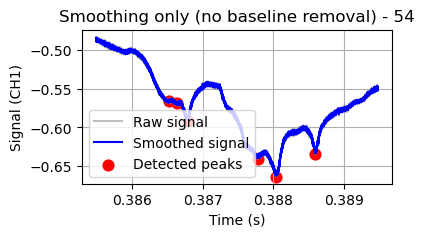

<Figure size 640x480 with 0 Axes>

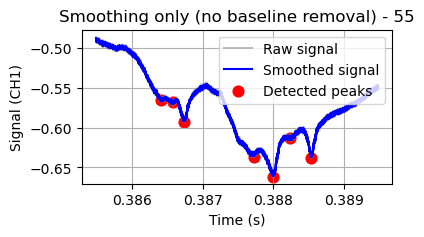

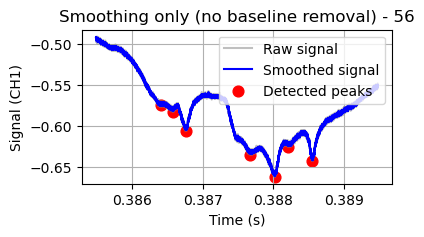

In [828]:
plt.figure()
plot_smoothed_signal(k-1)
plt.figure()
plot_smoothed_signal(k)

plot_smoothed_signal(k+1)

In [820]:
I = np.array([0, 0.01])
I = np.concatenate([I, np.linspace(0.05, 1.2, 24)])

idx = np.searchsorted(I, 0.99)   # 0.99이 들어갈 위치 계산
I = np.insert(I, idx, 0.99)
Y = np.linspace(0.1,0.4,16)
I = np.concatenate((I, Y))


print(I, len(I))

k = range(44, 87)   # 44 ~ 86
print(k[-1], len(k))

[0.   0.01 0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6
 0.65 0.7  0.75 0.8  0.85 0.9  0.95 0.99 1.   1.05 1.1  1.15 1.2  0.1
 0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36 0.38
 0.4 ] 43
86 43


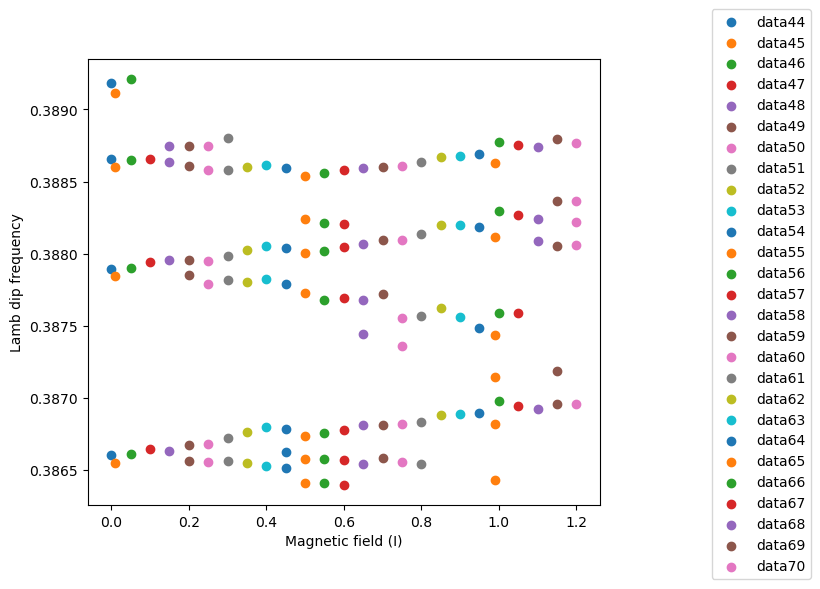

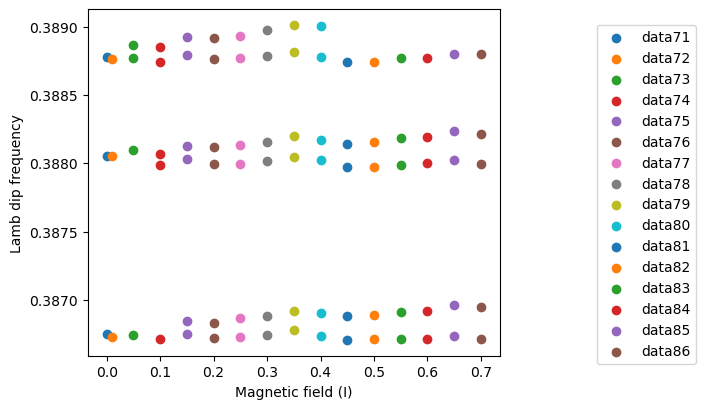

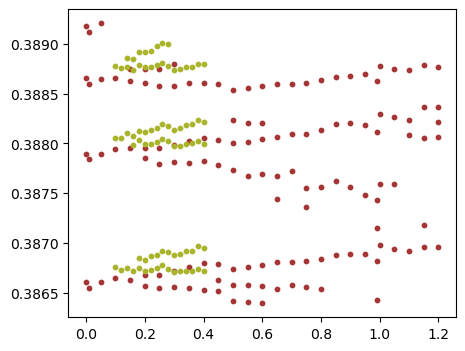

<Figure size 640x480 with 0 Axes>

In [899]:
fig, ax = plt.subplots(figsize=(6,5))

for idx, k in enumerate(range(44, 71)):
    y_values = globals()[f"data{k}_T"]
    x_values = np.full(len(y_values), I[idx])
    ax.scatter(x_values, y_values, label=f"data{k}")

fig.legend(loc='center left', bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.xlabel("Magnetic field (I)")
plt.ylabel("Lamb dip frequency")

plt.show()



fig, ax = plt.subplots(figsize=(5,4))

for idx, k in enumerate(range(71,87)):
    y_values = globals()[f"data{k}_T"]
    x_values = np.full(len(y_values), I[idx])
    ax.scatter(x_values, y_values, label=f"data{k}")

fig.legend(loc='center left', bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.xlabel("Magnetic field (I)")
plt.ylabel("Lamb dip frequency")
plt.show()



fig, ax = plt.subplots(figsize=(5,4))

# 첫 번째 그룹 (44~70)
for idx, k in enumerate(range(44,71)):
    y_values = globals()[f"data{k}_T"]
    x_values = np.full(len(y_values), I[idx])
    ax.scatter(x_values, y_values, s=10, color="#a53535")

# 두 번째 그룹 (71~86)
offset = 71 - 44   # = 27
for idx, k in enumerate(range(71,87)):
    y_values = globals()[f"data{k}_T"]
    x_values = np.full(len(y_values), I[idx + offset])
    ax.scatter(x_values, y_values, s=10, color="#a9b42a")



plt.figure()
def smoothed_signal(i):
    t = Time[i]
    y = CH1[i]

    win = 41
    y_smooth = savgol_filter(y, win, polyorder=3)

    # ----------------------------
    # Plot
    cmap = plt.cm.get_cmap('tab20')

    colour = cmap(np.random.randint(0, 20))

    cmap = plt.cm.get_cmap('hsv')   # 색이 전부 다른 계열
    #colour = cmap(np.random.rand())

    # ----------------------------
    #plt.plot(t, y, color='gray', alpha=0.5, label='Raw signal')
    plt.plot( t, y_smooth ,label=f'{i}', lw =0.5, color = colour)

    if f"data{i}_T" in globals() and f"data{i}_1" in globals():
        plt.scatter( globals()[f"data{i}_T"],globals()[f"data{i}_1"], c = colour, s=40, label="Detected peaks")



C:\Users\ainch\AppData\Local\Temp\ipykernel_35648\4156921617.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')
C:\Users\ainch\AppData\Local\Temp\ipykernel_35648\4156921617.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')   # 색이 전부 다른 계열
C:\Users\ainch\AppData\Local\Temp\ipykernel_35648\4156921617.py:71: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you i

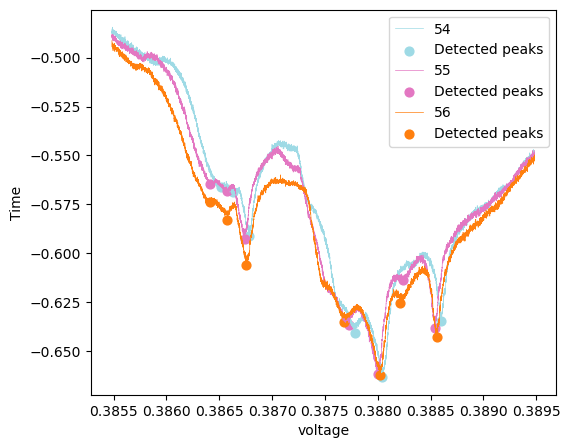

In [900]:
plt.figure(figsize=(6,5))
for i in [55]:
    smoothed_signal(i-1)
    smoothed_signal(i)
    smoothed_signal(i+1)
plt.ylabel("Time")
plt.xlabel("voltage")
plt.legend()

C:\Users\ainch\AppData\Local\Temp\ipykernel_35648\4156921617.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')
C:\Users\ainch\AppData\Local\Temp\ipykernel_35648\4156921617.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')   # 색이 전부 다른 계열
C:\Users\ainch\AppData\Local\Temp\ipykernel_35648\4156921617.py:71: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you i

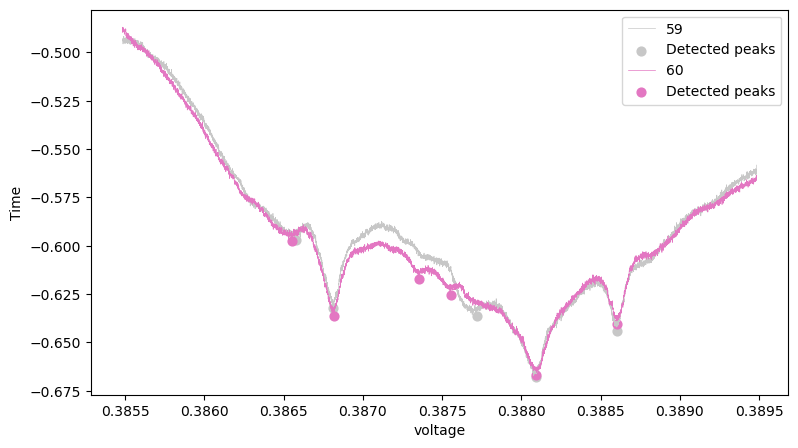

In [903]:
plt.figure(figsize=(9,5))
for i in range(59,61):
    smoothed_signal(i)
    plt.ylabel("Time")
plt.xlabel("voltage")
plt.legend()

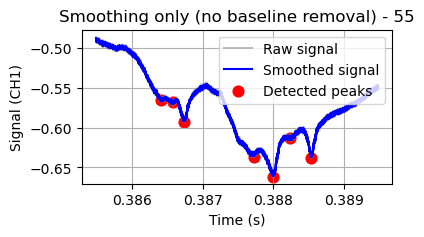

In [721]:
plot_smoothed_signal(55)

In [22]:
Time2 = {}
CH2_1 = {}
CH2_2 = {}

path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek20000.xlsx"
df = pd.read_excel(path, skiprows=20)
print(os.path.exists(path))
Time2[0] = df["TIME"]
CH2_1[0] = df["CH1"]

for i in range(1,8):  
    print(i)
    path = f"C:/Users/ainch/OneDrive - Durham University/OPTIC_3/data/tek2000{i}.xlsx"
    print(os.path.exists(path))
    #print("Reading:", path)
    df = pd.read_excel(path, skiprows=20)

    Time2[i] = df["TIME"]
    CH2_1[i] = df["CH1"]
    CH2_2[i] = df["CH2"]



True
1
True
2
True
3
True
4
True
5
True
6
True
7
True


c:\Users\ainch\anaconda3\envs\ppp\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\ainch\anaconda3\envs\ppp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


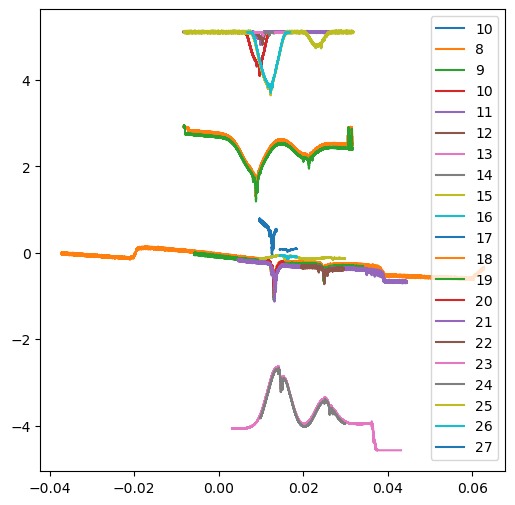

In [23]:
plt.figure(figsize=(6,6))
plt.plot(Time[10],CH1[10], label=f"{10}")
for i in range(8,28):  
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

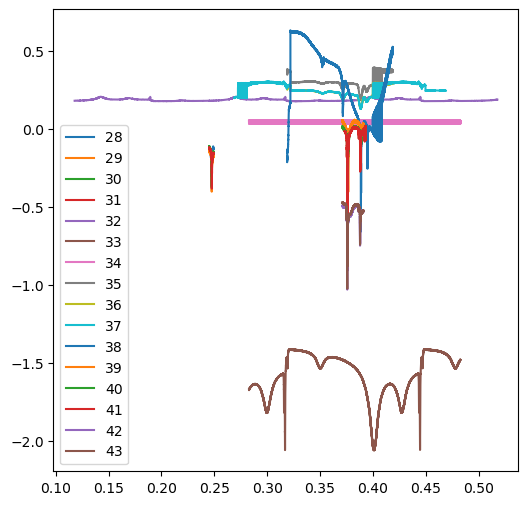

In [24]:
plt.figure(figsize=(6,6))
for i in range(28,44):  
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

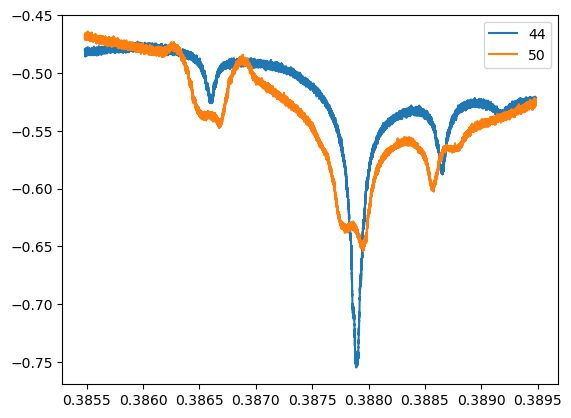

In [25]:
plt.plot(Time[44],CH1[44], label=f"{44}")
plt.plot(Time[50],CH1[50], label=f"{50}")
plt.legend()

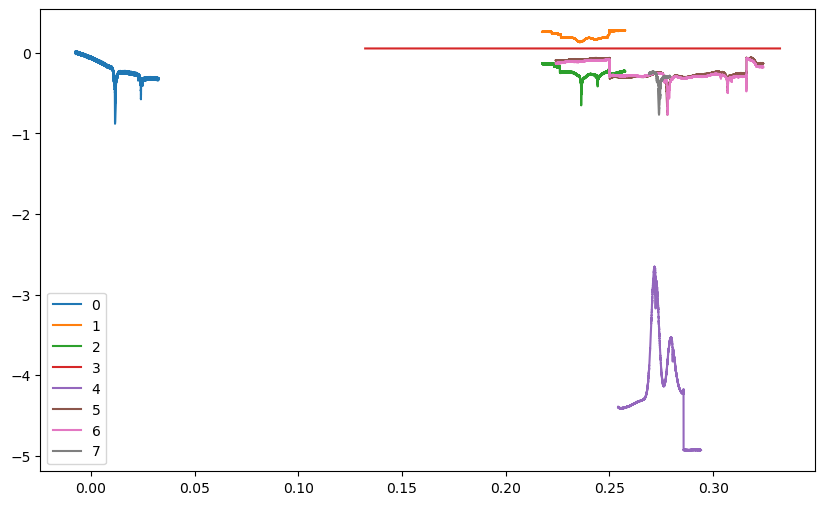

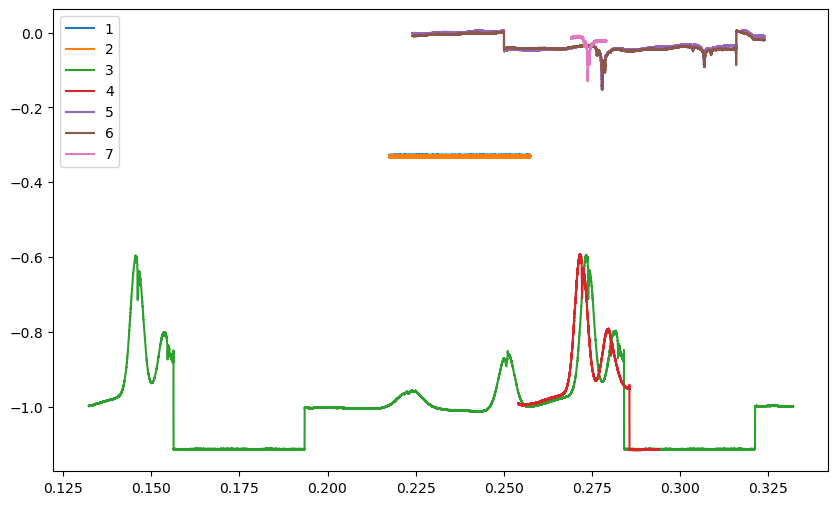

In [26]:
plt.figure(figsize=(10,6))
for i in range(0,8):  
    plt.plot(Time2[i],CH2_1[i], label=f"{i}")
plt.legend()
plt.figure(figsize=(10,6))
for i in range(1,8):  
    plt.plot(Time2[i], CH2_2[i], label=f"{i}")
plt.legend()


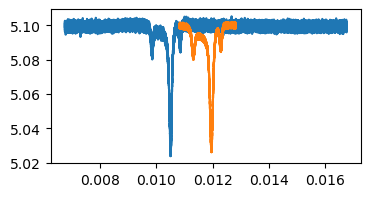

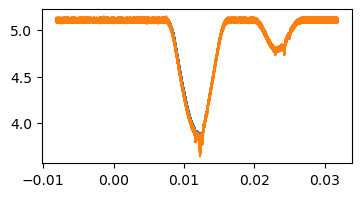

In [27]:
plt.figure(figsize=(4,2))
plt.plot(Time[13],CH1[13], label="CH1")
plt.plot(Time[14],CH1[14], label="CH1")
plt.figure(figsize=(4,2))
plt.plot(Time[16],CH1[16], label="CH1")
plt.plot(Time[15],CH1[15], label="CH1")

'2번 w.p.차이'

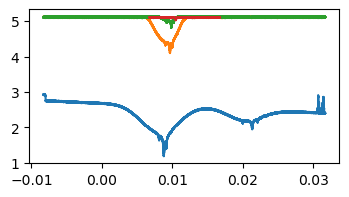

In [28]:
number = [9,10,11,13]
plt.figure(figsize=(4,2))
for i in number:
    plt.plot(Time[i],CH1[i], label="CH1")
    #plt.plot(Time[i], CH2[i], label="CH2")
'''2번 w.p.차이'''


'같은상태'

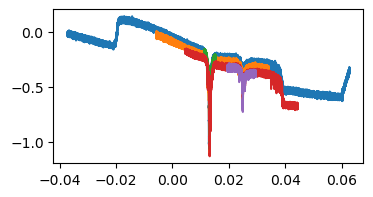

In [29]:
plt.figure(figsize=(4,2))
for i in range(18,23):
    plt.plot(Time[i],CH1[i], label="CH1")
    #plt.plot(Time[i], CH2[i], label="CH2")
'''같은상태'''

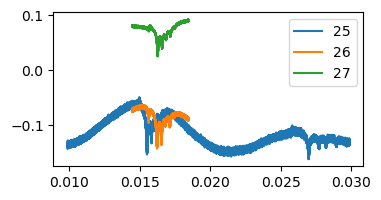

In [30]:
plt.figure(figsize=(4,2))
for i in range(25,28):
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

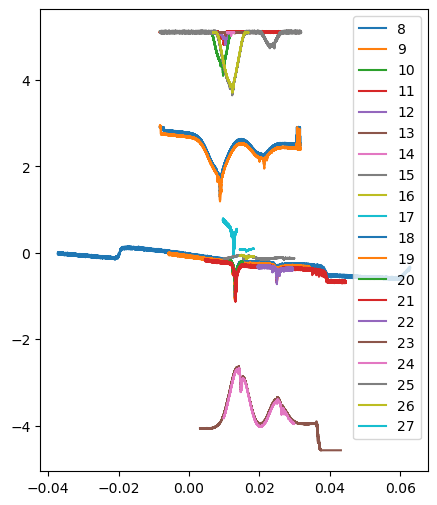

In [31]:
plt.figure(figsize=(5,6))
for i in range(8,28):
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

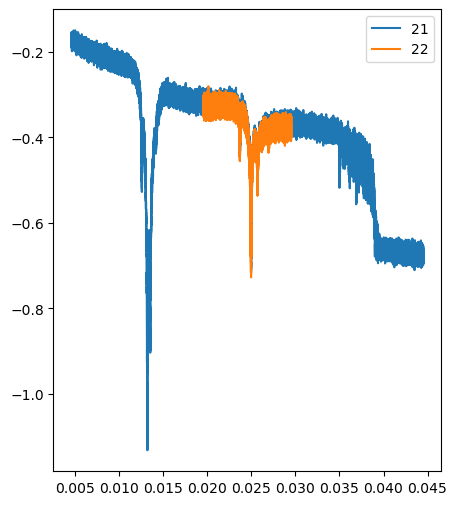

In [32]:
plt.figure(figsize=(5,6))
for i in range(21,23):
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()

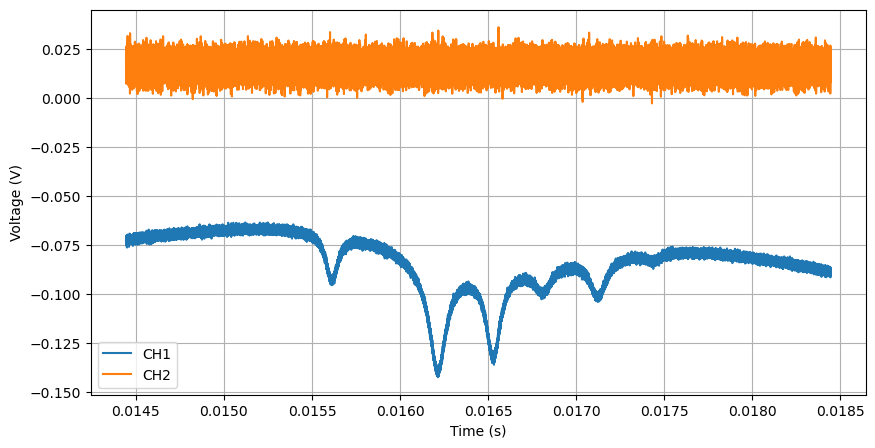

In [33]:
plt.figure(figsize=(10,5))
plt.plot(Time[26],CH1[26], label="CH1")
plt.plot(Time[26], CH2[26], label="CH2")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

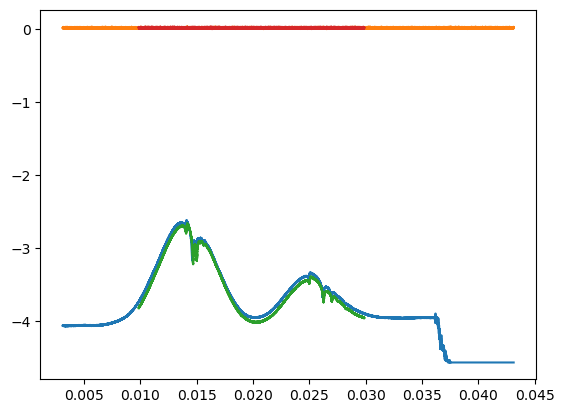

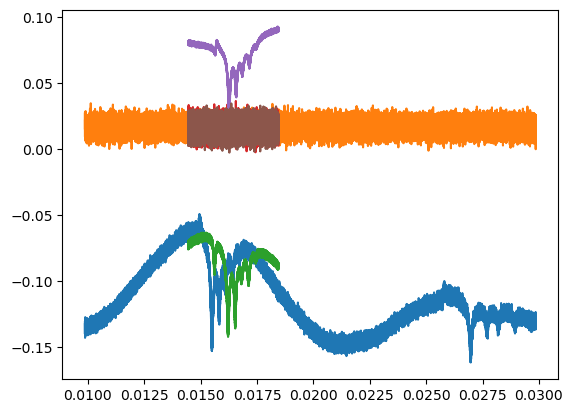

In [34]:
for i in range(23,25):
    plt.plot(Time[i],CH1[i], label="CH1")
    plt.plot(Time[i], CH2[i], label="CH2")
plt.figure()
for i in range(25,28):
    plt.plot(Time[i],CH1[i], label="CH1")
    plt.plot(Time[i], CH2[i], label="CH2")

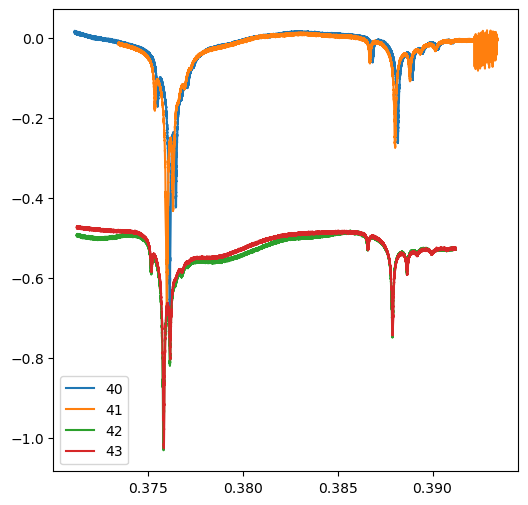

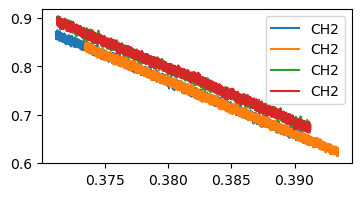

In [35]:
plt.figure(figsize=(6,6))
for i in range(40,44):  
    plt.plot(Time[i],CH1[i], label=f"{i}")
    #plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()
plt.figure(figsize=(4,2))
for i in range(40,44):  
    #plt.plot(Time[i],CH1[i], label=f"{i}")
    plt.plot(Time[i], CH2[i], label="CH2")
plt.legend()